## MONTE CARLO SENSITIVITY ANALYSIS
___
Cluster labels: 
* 0 – Core Frontline Operations Staff (E&I)
* 1 – Specialized Technical Field Experts (E&I)
* 2 – Advanced Governance & Support Specialists
* 3 – Essential Infrastructure Field Crew (E&I)
* 4 – Strategic Business & Real Estate Leaders
* 5 – Governance & Support Professionals

Python downstream analysis:
1. Erosion warning year distribution — all six scenarios
2. FRI confidence bands, E&I, 90% CI — six-panel small multiple
3. Tornado charts, parameter sensitivity on erosion warning year — six panels
4. Cluster 0 minimum E&I distributions — all six scenarios

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr

In [4]:
# DATASET PREPARATION
# Sensitivity Analysis · Scenarios A-F: 500 runs × 34 years × 6 scenarios = 102,000 rows
# Parameters varied: bScale, scoreOffset, quotaTimingOffset, quotaSizeScale, quotaFreqYears
# One state axis is classified here, not read from the model:
#   EROSION — friEI or friSSG falling below its own 2027 value by more than
#             0.10 (WARN) or 0.25 (CRIT) for two consecutive years
# Both tolerances are stipulated, not derived, and are declared as such in the manuscript.
# STAFFING carries no state labels. The 60/40 headcount thresholds used previously had no derivation in any upstream notebook or architecture document and were abandoned rather than corrected. Staffing is summarised descriptively: final headcount, minimum headcount, and the year the workforce first falls below half its 2027 baseline. The exported 'warning' and 'crisis' columns are the superseded composite trigger and are deliberately not used.

ERO_WARN, ERO_CRIT = 0.10, 0.25
CONSEC = 2

PARAMS = ['bScale', 'scoreOffset', 'quotaTimingOffset', 'quotaSizeScale', 'quotaFreqYears']

# The common 2027 population is 7,925 in all six scenarios. Scenario E's Monte Carlo exports record 7,891 at 2027 because applyOutsourcing runs at the end of annualMonitor and removes 34 agents before the first row is written, so the exported headcount cannot be used as the baseline. It is taken instead from the deterministic export, whose cluster counts are computed before outsourcing.
_det_base = pd.read_csv('SCENARIOAF.csv')
_det_base['total'] = _det_base[[f'count_{i}' for i in range(6)]].sum(axis=1)
_base_by_scenario = _det_base.groupby('scenarioID')['total'].first()
assert _base_by_scenario.nunique() == 1, \
    f'2027 baseline differs across scenarios: {_base_by_scenario.to_dict()}'
BASELINE_2027 = int(_base_by_scenario.iloc[0])

frames = []
for sid in range(6):
    f = pd.read_csv(f'MC_SCENARIO{sid}.csv')
    assert f['scenarioID'].nunique() == 1 and f['scenarioID'].iloc[0] == sid, \
        f'MC_SCENARIO{sid}.csv carries scenarioID {f["scenarioID"].unique()}'
    frames.append(f)
mc = pd.concat(frames, ignore_index=True)
mc['simYearInt'] = mc['simYear'].round().astype(int)
mc = mc.sort_values(['scenarioID', 'run', 'simYearInt']).reset_index(drop=True)

def summarise(g):
    """One row per run: erosion trigger years plus descriptive headcount statistics."""
    g = g.reset_index(drop=True)
    base_ei, base_ssg = g['friEI'].iloc[0], g['friSSG'].iloc[0]
    out = {'eroWarn': np.nan, 'eroCrit': np.nan}
    run_w = run_c = 0
    for i in range(len(g)):
        d_ei  = base_ei  - g['friEI'].iloc[i]
        d_ssg = base_ssg - g['friSSG'].iloc[i]
        run_w = run_w + 1 if (d_ei > ERO_WARN or d_ssg > ERO_WARN) else 0
        run_c = run_c + 1 if (d_ei > ERO_CRIT or d_ssg > ERO_CRIT) else 0
        if np.isnan(out['eroWarn']) and run_w >= CONSEC:
            out['eroWarn'] = g['simYearInt'].iloc[i]
        if np.isnan(out['eroCrit']) and run_c >= CONSEC:
            out['eroCrit'] = g['simYearInt'].iloc[i]

    base_head = BASELINE_2027
    halved = g.loc[g['headcount'] < base_head / 2, 'simYearInt']
    out['baseHeadcount']  = base_head
    out['finalHeadcount'] = g['headcount'].iloc[-1]
    out['minHeadcount']   = g['headcount'].min()
    out['pctOfBaseline']  = 100.0 * g['headcount'].iloc[-1] / base_head
    out['halvingYear']    = halved.iloc[0] if len(halved) else np.nan
    out['minFriEI']       = g['friEI'].min()
    for p in PARAMS:
        out[p] = g[p].iloc[0]
    return pd.Series(out)

rsummary = (
    mc.groupby(['scenarioID', 'run'])
      .apply(summarise, include_groups=False)
      .reset_index()
)

SLABELS = {
    0: 'Scenario A · Intended Baseline',
    1: 'Scenario B · Periodic Quota Continuation',
    2: 'Scenario C · Extended Retirement Age',
    3: 'Scenario D · Extended Retirement + Periodic Quota',
    4: 'Scenario E · Accelerated Outsourcing',
    5: 'Scenario F · Complete No-Quota',
}
SSHORT = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F'}
SCOLOURS = {
    0: '#2980B9', 1: '#27AE60', 2: '#F39C12',
    3: '#8E44AD', 4: '#17A589', 5: '#C0392B',
}
SORDER = [5, 2, 0, 4, 1, 3]   # worst to best on final headcount

print(f'# TOTAL ROWS        : {len(mc):,}')
print(f'SCENARIOS           : {sorted(mc["scenarioID"].unique())}')
print(f'# RUNS PER SCENARIO : {mc.groupby("scenarioID")["run"].nunique().to_dict()}')
print(f'YEARS PER RUN       : {mc.groupby("scenarioID")["simYearInt"].nunique().unique()}')
print()
print('EROSION TRIGGERS AND HEADCOUNT SPREAD (500 runs per scenario)')
print(f'{"":4s}{"eroWARN":>9s}{"eroCRIT":>9s}{"2060 headcount range":>24s}{"invariant":>11s}')
for sid in SORDER:
    r = rsummary[rsummary['scenarioID'] == sid]
    lo, hi = int(r['finalHeadcount'].min()), int(r['finalHeadcount'].max())
    rng = f'{lo:,}' if lo == hi else f'{lo:,}\u2013{hi:,}'
    inv = mc[mc['scenarioID'] == sid].groupby('simYearInt')['headcount'].nunique().max() == 1
    print(f'{SSHORT[sid]:4s}'
          f'{r["eroWarn"].notna().sum():9d}'
          f'{r["eroCrit"].notna().sum():9d}'
          f'{rng:>24s}'
          f'{("yes" if inv else "no"):>11s}')

# TOTAL ROWS        : 102,000
SCENARIOS           : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
# RUNS PER SCENARIO : {0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500}
YEARS PER RUN       : [34]

EROSION TRIGGERS AND HEADCOUNT SPREAD (500 runs per scenario)
      eroWARN  eroCRIT    2060 headcount range  invariant
F           0        0                     475        yes
C           0        0                   1,268        yes
A          89        0                   2,317        yes
E          91        0             2,247–2,265         no
B          93        0             5,143–7,517         no
D          38        0             6,924–9,318         no


In [5]:
# MC PLOT 1A — STAFFING TRAJECTORY (TABLE)
# The staffing axis carries no state labels. The 60/40 headcount thresholds used in earlier versions had no derivation in any upstream notebook or architecture document and were abandoned rather than corrected. Staffing is reported as descriptive statistics on the trajectory, with the Monte Carlo range alongside. All state labels now belong to the erosion axis alone, plotted below.

det = pd.read_csv('SCENARIOAF.csv')
CLUSTER_COLS = [f'count_{i}' for i in range(6)]
det['total'] = det[CLUSTER_COLS].sum(axis=1)

print('STAFFING TRAJECTORY · DETERMINISTIC RUN, WITH MONTE CARLO RANGE AT 2060')
print(f'{"":3s}{"PEAK":>13s}{"2060":>8s}{"% OF 2027":>11s}{"HALVES":>9s}{"MC 2060 RANGE":>18s}')
for sid in SORDER:
    d = det[det['scenarioID'] == sid].reset_index(drop=True)
    base = d['total'].iloc[0]
    peak_yr = int(d.loc[d['total'].idxmax(), 'year'])
    peak = int(d['total'].max())
    end = int(d['total'].iloc[-1])
    below = d[d['total'] < base / 2]
    halves = str(int(below['year'].iloc[0])) if len(below) else 'never'
    m = mc[(mc['scenarioID'] == sid) & (mc['simYearInt'] == 2060)]['headcount']
    rng = f'{int(m.min()):,}' if m.min() == m.max() else f'{int(m.min()):,}\u2013{int(m.max()):,}'
    print(f'{SSHORT[sid]:3s}{f"{peak:,} ({peak_yr})":>13s}{end:>8,}'
          f'{100 * end / base:>10.1f}%{halves:>9s}{rng:>18s}')
print(f'\nBaseline 2027 = {BASELINE_2027:,} agents in all six scenarios.')
print()

STAFFING TRAJECTORY · DETERMINISTIC RUN, WITH MONTE CARLO RANGE AT 2060
            PEAK    2060  % OF 2027   HALVES     MC 2060 RANGE
F   7,925 (2027)     475       6.0%     2041               475
C   7,925 (2027)   1,268      16.0%     2046             1,268
A   9,347 (2032)   2,317      29.2%     2056             2,317
E   9,222 (2032)   2,253      28.4%     2056       2,247–2,265
B   9,347 (2032)   6,717      84.8%    never       5,143–7,517
D  10,775 (2032)   8,518     107.5%    never       6,924–9,318

Baseline 2027 = 7,925 agents in all six scenarios.



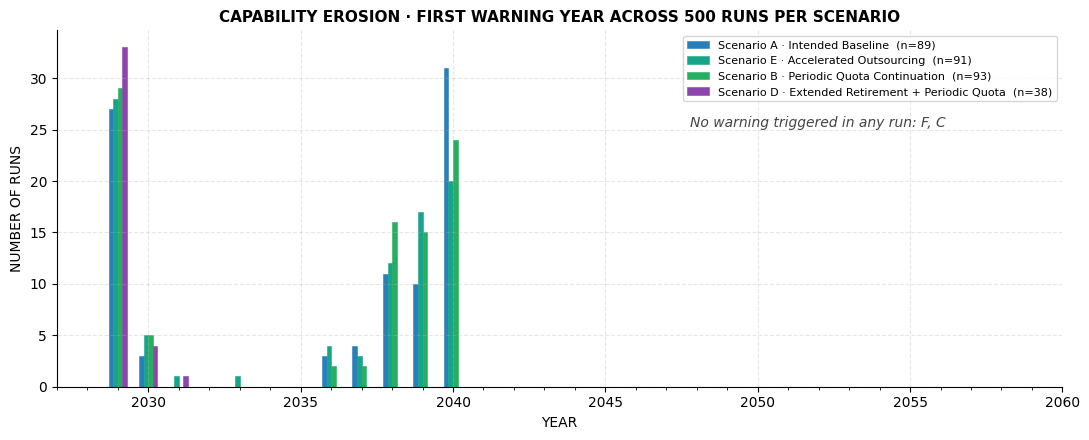

In [22]:
# MC PLOT 1B — EROSION AXIS (DISTRIBUTION)
# Bars are offset by position among the scenarios that actually triggered, not by position in SORDER, so the group stays centred on its year when a scenario records zero warnings and is skipped. The y limit is computed rather than fixed, so a taller distribution cannot be clipped silently.
BARWIDTH = 0.15
drawn, silent = [], []
for sid in SORDER:
    subset = rsummary[rsummary['scenarioID'] == sid]['eroWarn'].dropna().astype(int)
    if len(subset) == 0:
        silent.append(SSHORT[sid])
        continue
    drawn.append((sid, subset.value_counts().sort_index(), len(subset)))
centre = (len(drawn) - 1) / 2.0

fig, ax = plt.subplots(figsize=(11, 4.5))
for k, (sid, counts, n) in enumerate(drawn):
    ax.bar(counts.index + (k - centre) * BARWIDTH, counts.values,
           width=BARWIDTH, color=SCOLOURS[sid], edgecolor=SCOLOURS[sid],
           linewidth=0.4, label=f'{SLABELS[sid]}  (n={n})')
ax.set_title('CAPABILITY EROSION · FIRST WARNING YEAR ACROSS 500 RUNS PER SCENARIO', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF RUNS')
ax.set_xlim(2027, 2060)
ax.set_ylim(0, max(c.max() for _, c, _ in drawn) * 1.05)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
if silent:
    ax.text(0.63, 0.73, f"No warning triggered in any run: {', '.join(silent)}", transform=ax.transAxes, fontsize=10, style='italic', color='#444444')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('F9_erosion_warning.png', dpi=600, bbox_inches='tight')
plt.show();

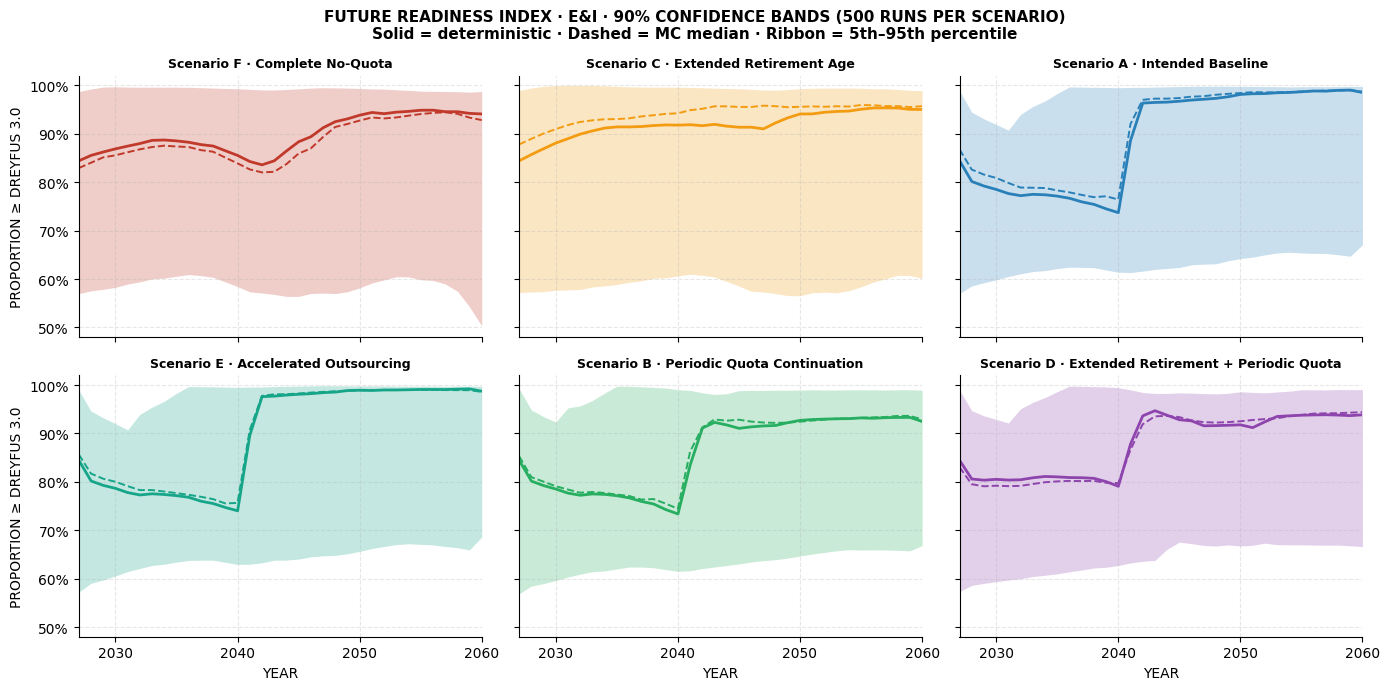

In [10]:
# MC PLOT 2 — FRI CONFIDENCE BANDS · E&I · 90% CI · ALL SIX SCENARIOS
# Median + 5th-95th percentile ribbon per scenario, deterministic result overlaid.
# E&I only: it is the Tier 1 safety-critical dimension and the one that drives the erosion trigger. The other three dimensions are in Plot 2b (supplementary).
# NOTE: SORDER, SSHORT, SCOLOURS and SLABELS come from the preparation cell and are deliberately NOT redefined here.

det = pd.read_csv('SCENARIOAF.csv')
def cbands(df, col):
    return (
        df.groupby(['scenarioID', 'simYearInt'])[col]
        .agg(
            median=lambda x: x.quantile(0.50),
            lo=lambda x: x.quantile(0.05),
            hi=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )

bands = cbands(mc, 'friEI')
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, sid in zip(axes.flatten(), SORDER):
    colour = SCOLOURS[sid]
    b = bands[bands['scenarioID'] == sid]
    ax.fill_between(b['simYearInt'], b['lo'], b['hi'], color=colour, alpha=0.25, linewidth=0)
    ax.plot(b['simYearInt'], b['median'], color=colour, linewidth=1.4, linestyle='--')
    det_s = det[det['scenarioID'] == sid]
    ax.plot(det_s['year'], det_s['friEI'], color=colour, linewidth=2.0, linestyle='-')
    ax.set_title(SLABELS[sid], fontsize=9, fontweight='bold')
    ax.set_xlim(2027, 2060)
    ax.set_ylim(0.48, 1.02)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.grid(True, linestyle='--', alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel('YEAR')
for ax in axes[:, 0]:
    ax.set_ylabel('PROPORTION ≥ DREYFUS 3.0')
fig.suptitle('FUTURE READINESS INDEX · E&I · 90% CONFIDENCE BANDS (500 RUNS PER SCENARIO)\n'
             'Solid = deterministic · Dashed = MC median · Ribbon = 5th–95th percentile',
             fontsize=11, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('F10_fri_ei_bands.png', dpi=600, bbox_inches='tight')
plt.show();

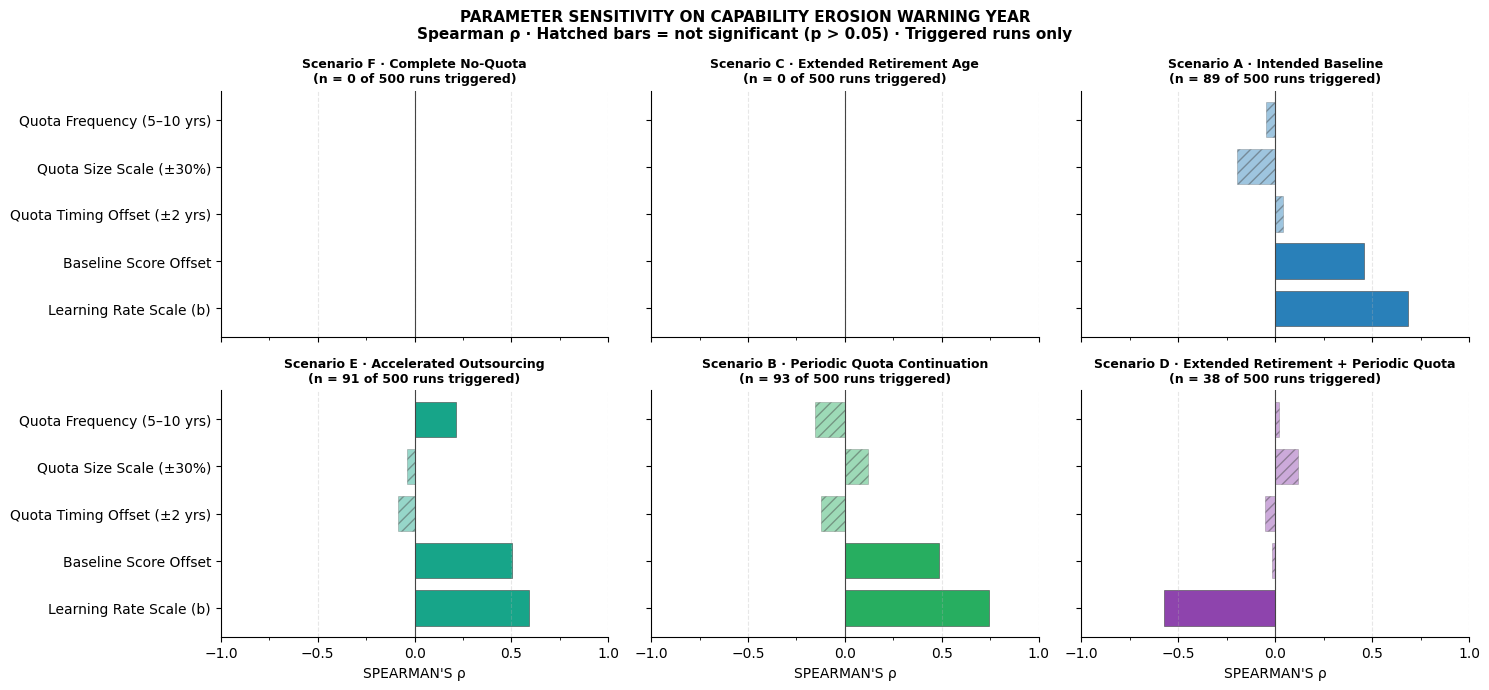

In [11]:
# MC PLOT 3 — TORNADO CHART · PARAMETER SENSITIVITY ON EROSION WARNING YEAR
# Spearman rank correlation between each parameter and the first capability-erosion warning year, per scenario, over runs where that warning triggered.
# The staffing axis is NOT analysed here: its trigger years are constant across runs in all six scenarios, so rank correlation against them is undefined. That invariance is itself the finding, and is reported in the Plot 1 table.
# NOTE: SORDER, SLABELS, SCOLOURS and PARAMS come from the preparation cell.

PARAM_LABELS = {
    'bScale':            'Learning Rate Scale (b)',
    'scoreOffset':       'Baseline Score Offset',
    'quotaTimingOffset': 'Quota Timing Offset (±2 yrs)',
    'quotaSizeScale':    'Quota Size Scale (±30%)',
    'quotaFreqYears':    'Quota Frequency (5–10 yrs)',
}
MIN_N = 30   # below this, rank correlation is not reported

records = []
for sid in SORDER:
    subset = rsummary[(rsummary['scenarioID'] == sid) & rsummary['eroWarn'].notna()]
    for param in PARAM_LABELS:
        if len(subset) < MIN_N or subset[param].nunique() < 2:
            records.append({'scenarioID': sid, 'param': param, 'rho': np.nan, 'pval': np.nan, 'n': len(subset)})
            continue
        rho, pval = spearmanr(subset[param], subset['eroWarn'])
        records.append({'scenarioID': sid, 'param': param, 'rho': rho, 'pval': pval, 'n': len(subset)})
corr = pd.DataFrame(records)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
for ax, sid in zip(axes.flatten(), SORDER):
    sub = corr[corr['scenarioID'] == sid].set_index('param').reindex(PARAM_LABELS.keys())
    colour = SCOLOURS[sid]
    bars = ax.barh([PARAM_LABELS[p] for p in PARAM_LABELS],
                   sub['rho'].fillna(0.0),
                   color=colour, edgecolor='#444444', linewidth=0.4, height=0.75)
    for bar, (_, row) in zip(bars, sub.iterrows()):
        if pd.isna(row['pval']) or row['pval'] > 0.05:
            bar.set_hatch('///')
            bar.set_alpha(0.45)
    n = int(sub['n'].iloc[0])
    ax.axvline(0, color='#444444', linewidth=0.8)
    ax.set_xlim(-1.0, 1.0)
    ax.set_title(f'{SLABELS[sid]}\n(n = {n} of 500 runs triggered)', fontsize=9, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.25))
    ax.grid(True, axis='x', linestyle='--', alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("SPEARMAN'S ρ")
fig.suptitle(
    'PARAMETER SENSITIVITY ON CAPABILITY EROSION WARNING YEAR\n'
    'Spearman ρ · Hatched bars = not significant (p > 0.05) · Triggered runs only',
    fontsize=11, fontweight='bold'
)
sns.despine()
plt.tight_layout()
plt.savefig('F11_tornado_erosion.png', dpi=600, bbox_inches='tight')
plt.show();

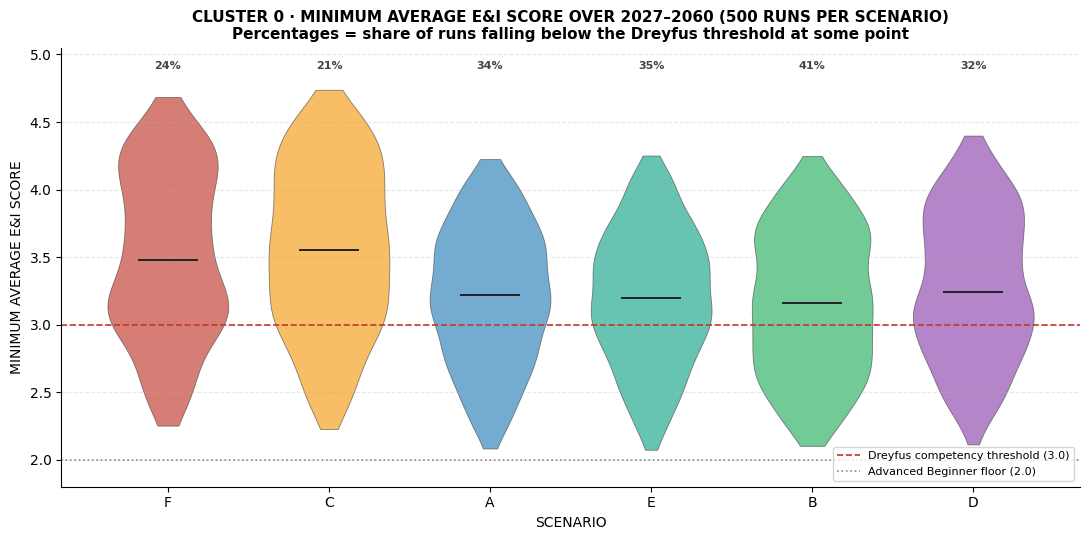

In [23]:
# MC PLOT 4 — CLUSTER 0 MINIMUM E&I DISTRIBUTIONS · ALL SIX SCENARIOS
# Distribution of the lowest cluster-average E&I score reached at any point in the 34-year horizon, across 500 runs per scenario.
# Cluster 0 only: Clusters 1 and 3 never fall below 3.45 in any run of any scenario, so their distributions carry no information about threshold risk and are reported in text rather than plotted.

rmin = (
    mc.groupby(['scenarioID', 'run'])
      .agg(minEI0=('minEI0', 'min'),
           minEI1=('minEI1', 'min'),
           minEI3=('minEI3', 'min'))
      .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5.5))
data, positions, ticks = [], [], []
for i, sid in enumerate(SORDER):
    vals = rmin[rmin['scenarioID'] == sid]['minEI0'].dropna().values
    data.append(vals)
    positions.append(i + 1)
    ticks.append(SSHORT[sid])

parts = ax.violinplot(data, positions=positions, widths=0.75, showmedians=True, showextrema=False)
for body, sid in zip(parts['bodies'], SORDER):
    body.set_facecolor(SCOLOURS[sid])
    body.set_edgecolor('#444444')
    body.set_alpha(0.65)
    body.set_linewidth(0.6)
parts['cmedians'].set_color('#222222')
parts['cmedians'].set_linewidth(1.4)

for i, sid in enumerate(SORDER):
    v = rmin[rmin['scenarioID'] == sid]['minEI0']
    ax.text(i + 1, 4.95, f'{100 * (v < 3.0).mean():.0f}%', ha='center', va='top', fontsize=8, fontweight='bold', color='#444444')

ax.axhline(3.0, color='#C0392B', linestyle='--', linewidth=1.2, label='Dreyfus competency threshold (3.0)')
ax.axhline(2.0, color='#888888', linestyle=':', linewidth=1.2, label='Advanced Beginner floor (2.0)')
ax.set_title('CLUSTER 0 · MINIMUM AVERAGE E&I SCORE OVER 2027–2060 (500 RUNS PER SCENARIO)\n'
             'Percentages = share of runs falling below the Dreyfus threshold at some point',
             fontsize=11, fontweight='bold')
ax.set_xlabel('SCENARIO')
ax.set_ylabel('MINIMUM AVERAGE E&I SCORE')
ax.set_xticks(positions)
ax.set_xticklabels(ticks)
ax.set_ylim(1.8, 5.05)
ax.yaxis.set_major_locator(MaxNLocator(nbins=7))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('F12_cluster0_minEI.png', dpi=600, bbox_inches='tight')
plt.show();

___
**END**